# 0. 환경설정

In [1]:
pip install pymysql sqlalchemy pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from sqlalchemy import create_engine

In [3]:
%pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# 1) 접속 정보 설정
USER = "root"          # MySQL 계정
PASSWORD = "123456"
HOST = "localhost"     # 도커 컨테이너를 호스트로 포워딩했으면 보통 localhost
PORT = "3400"          # docker run -p 3306:3306 했다고 가정
DB = "docker_mysql"   # 사용 중인 DB 이름

In [5]:
# 2) SQLAlchemy 엔진 생성
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}?charset=utf8mb4")

# 1. 데이터 불러오기

In [70]:
accounts_paymenthistory = """
select * from accounts_paymenthistory
"""

polls_question = """
SELECT * FROM polls_question
"""

In [71]:
question_df = pd.read_sql(polls_question, con=engine)
question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [33]:
payment_df = pd.read_sql(accounts_paymenthistory, con=engine)
payment_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [9]:
payment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95140 entries, 0 to 95139
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          95140 non-null  int64         
 1   productId   95140 non-null  object        
 2   phone_type  95140 non-null  object        
 3   created_at  95140 non-null  datetime64[ns]
 4   user_id     95140 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.6+ MB


## 2-1. payment_df 기본 전처리
- 결측치 없음
- 범주형 데이터: phone_type

In [18]:
for col in payment_df.columns:
    print(len(payment_df[payment_df[col] == '']))

0
0
0
0
0


In [16]:
payment_df['phone_type'].unique()

array(['A', 'I'], dtype=object)

In [30]:
# created_at, user_id 중복값 531개
payment_df[['created_at', 'user_id']].duplicated().sum()

np.int64(531)

In [24]:
payment_df[payment_df[['created_at', 'user_id']].duplicated(keep=False)].sort_values('user_id')

,id,productId,phone_type,created_at,user_id
94951,97890,heart.1000,I,2024-03-09 14:30:56,838932
94950,97889,heart.1000,I,2024-03-09 14:30:56,838932
94155,97094,heart.777,I,2023-10-08 18:18:43,839578
94154,97093,heart.777,I,2023-10-08 18:18:43,839578
94153,97092,heart.777,I,2023-10-08 18:18:43,839578
...,...,...,...,...,...
94018,96957,heart.777,I,2023-09-27 10:41:13,1580828
94020,96959,heart.777,I,2023-09-27 10:41:31,1580828
94021,96960,heart.777,I,2023-09-27 10:41:31,1580828
94229,97168,heart.777,I,2023-10-20 12:57:25,1581215


In [35]:
# 중복되는 created_at 제거
payment_df = payment_df.drop_duplicates(['created_at', 'user_id'])
payment_df[['created_at', 'user_id']].duplicated().sum()

np.int64(0)

# 2-2. 매출
- 총 매출: 200,264,100원
- 월 매출: 5월 최대 매출 기록후 꾸준히 하락(2023-05 ~ 2024-05)
- 주 매출?

In [37]:
payment_df.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


- 200 - 900원
- 777 - 1900원
- 1000 - 2900원
- 4000 - 9900원


In [38]:
payment_df['productId'].unique()

array(['heart.777', 'heart.200', 'heart.4000', 'heart.1000'], dtype=object)

In [42]:
heart_price = {
    'heart.200': 900,
    'heart.777': 1900,
    'heart.1000': 2900,
    'heart.4000':  9900
}

payment_df['price'] = payment_df['productId'].map(heart_price)
payment_df.head()

,id,productId,phone_type,created_at,user_id,price
0,6,heart.777,A,2023-05-13 21:28:34,1211127,1900
1,7,heart.777,A,2023-05-13 21:29:39,1151343,1900
2,8,heart.777,A,2023-05-13 21:31:33,1002147,1900
3,9,heart.777,A,2023-05-13 21:31:39,1095040,1900
4,11,heart.777,A,2023-05-13 21:34:32,1164081,1900


In [89]:
# 월별 매출
monthly_sales = payment_df.groupby(payment_df['created_at'].dt.strftime('%Y-%m'))['price'].sum().reset_index()

monthly_sales = monthly_sales.sort_values('price', ascending=False)
monthly_sales['rate'] = monthly_sales['price'] / payment_df['price'].sum()
monthly_sales

,created_at,price,rate
0,2023-05,174733400,0.872515
1,2023-06,16168100,0.080734
2,2023-07,4223900,0.021092
3,2023-08,2765400,0.013809
4,2023-09,845500,0.004222
5,2023-10,339200,0.001694
6,2023-11,308300,0.001539
7,2023-12,280400,0.001400
8,2024-01,226000,0.001129
11,2024-04,135900,0.000679


In [90]:
# 총 매출
total_price = payment_df['price'].sum()
print(f'총 매출: {total_price:,.0f}원')

총 매출: 200,264,100원


In [88]:
heart_count = {
    'heart.200': 200,
    'heart.777': 777,
    'heart.1000': 1000,
    'heart.4000':  4000
}

payment_df['heart_count'] = payment_df['productId'].map(heart_count)
payment_df.head()

,id,productId,phone_type,created_at,user_id,price,heart_count
0,6,heart.777,A,2023-05-13 21:28:34,1211127,1900,777
1,7,heart.777,A,2023-05-13 21:29:39,1151343,1900,777
2,8,heart.777,A,2023-05-13 21:31:33,1002147,1900,777
3,9,heart.777,A,2023-05-13 21:31:39,1095040,1900,777
4,11,heart.777,A,2023-05-13 21:34:32,1164081,1900,777


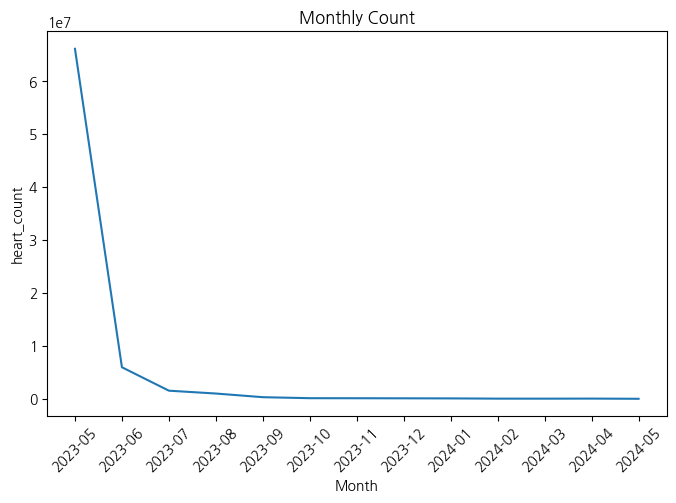

In [91]:
# 월별 판매 하트 개수
monthly_count = payment_df.groupby(payment_df['created_at'].dt.strftime('%Y-%m'))['heart_count'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=monthly_count,
    x='created_at',
    y='heart_count'
)

plt.title('Monthly Count')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

In [92]:
monthly_count

,created_at,heart_count
0,2023-05,66181697
1,2023-06,5971828
2,2023-07,1544293
3,2023-08,1005652
4,2023-09,312588
5,2023-10,125507
6,2023-11,115445
7,2023-12,102482
8,2024-01,85390
9,2024-02,41241


In [63]:
16168100/174733400

0.09253010586413359

- 2023-05 매출(약 1억 7천만원) 전체 매출의 87.2% 비중
- 2023-06 매출(약1천 6백만원)은 전월 대비  9.2%로 급락함
- 이후 달을 거듭할수록 매출 꾸준히 감소하여 2024-05년 최저 매출 기록
- 하트 판매량도 마찬가지

의문점
- paymenthistory는 2023-05-13부터 집계가 됨
- 하지만 **ping_question은 2023-03월부터 집계됨**
- 2023-04까지 ping 이용률이 저조하다가, paymenthistory 집계 시작일(5월 13일)부터 이용량 급증
- 1.5 업데이트는 유료화로 전환이 아니라, 서비스 특성상 ping을 시작하려면 정해진 인원수가 모여야 시작할 수 있는데, 유저가 부족해서 5월 이전에는 저조했을 것으로 추측
- 따라서 이용량이 급증한 05-13부터 집계를 시작했을 것으로 판단. -> 가설

In [68]:
print(payment_df['created_at'].min())
print(payment_df[payment_df['created_at'] > '2023-05-14']['created_at'].min())
print(payment_df[payment_df['created_at'] > '2023-05-15']['created_at'].min())
print(payment_df[payment_df['created_at'] > '2023-05-16']['created_at'].min())
print(payment_df[payment_df['created_at'] > '2023-05-17']['created_at'].min())
print(payment_df[payment_df['created_at'] > '2023-05-18']['created_at'].min())

2023-05-13 21:28:34
2023-05-14 00:00:29
2023-05-15 00:02:21
2023-05-16 00:00:53
2023-05-17 00:00:43
2023-05-18 00:00:44


- 13일을 제외한 날은 00시부터 집계 됐지만 13만 21시 28시부터 집계됨

-> ping_question 테이블이 5월 13일부터 집계된 이유는 하트 구매량이이 급증해서 새로 생성한 테이블이다.

In [69]:
print(payment_df['created_at'].max())

2024-05-08 14:12:45


# 3. question_df 기본 전처리

In [72]:
question_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             5025 non-null   int64         
 1   question_text  5025 non-null   object        
 2   created_at     5025 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 117.9+ KB


In [73]:
# 질문 내용과 질문 일자로 구성되어 있음
# id가 99번부터 시작??
question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [74]:
# 중복값 존재
for col in question_df.columns:
    print(question_df[col].duplicated().sum())

0
1122
4381


In [75]:
# 결측치 없음
for col in question_df.columns:
    print(question_df[col].isnull().sum())

0
0
0


In [83]:
for col in question_df.columns:
    print(len(question_df[question_df[col] == '']))

0
0
0


# 3-2. 질문 사용량

In [84]:
question_df.head()

,id,question_text,created_at
0,99,가장 신비한 매력이 있는 사람은?,2023-03-31 15:22:53
1,100,"""이 사람으로 한 번 살아보고 싶다"" 하는 사람은?",2023-03-31 15:22:53
2,101,미래의 틱톡커는?,2023-03-31 15:22:54
3,102,여기서 제일 특이한 친구는?,2023-03-31 15:22:54
4,103,가장 지켜주고 싶은 사람은?,2023-03-31 15:22:55


In [86]:
question_df.groupby(question_df['created_at'].dt.strftime('%Y-%m'))['question_text'].size().reset_index()

,created_at,question_text
0,2023-03,73
1,2023-04,154
2,2023-05,1309
3,2023-06,3489


- 3월에 출시했을 것으로 판단
- 집계기간은 3월~6월 (4개월)
- ping 사용량이 증가하는 추세. 2배 이상씩 사용량 증가

# 4-1. 가입자 수
- 매출은 하락 추세, 질문 사용량은(3월~6월) 상승 추세이다.
- 하지만 질문 사용량도 이후 하락 추세로 전환됐을 것으로 판단된다. 이를 뒷바침하기 위해 가입자 수를 확인할 필요가 있다.

- -> hackle_df는 집계 기간이 2023-07 ~ 08이라서 월별 회원가입자 수를 확인할 수 없음
- 7월 일 평균 가입자 수는 48명, 8월 일 평균 가입자 수는 29명으로 줄어듬
- 매출이 감소 추세이기 때문에 가입자 수도 점차 감소할 것으로 판단

In [94]:
hackle_query = """
SELECT * FROM hackle_events;
"""

In [95]:
hackle_df = pd.read_sql(hackle_query, con=engine)
hackle_df.head()

,event_id,event_datetime,event_key,session_id,id,item_name,page_name,friend_count,votes_count,heart_balance,question_id
0,00000533-3f1c-4b3b-81f1-0c8f35754b4e,2023-07-18 19:40:17,$session_start,4OzYh3seq3VKytpSn5pvQkZNQii1,00000533-3f1c-4b3b-81f1-0c8f35754b4e,,,NaN,NaN,NaN,NaN
1,00000716-27e9-4e72-a602-d0ce61784b06,2023-07-18 21:07:24,click_question_open,8QXy31PQxbW9qLzq0Y1dhR8Ypm52,00000716-27e9-4e72-a602-d0ce61784b06,,,64.0,436.0,4830.0,NaN
2,000007c8-68ce-40e6-9b1e-f0e34e8ff9cc,2023-08-06 20:18:03,click_bottom_navigation_profile,6bcea65d-9f40-46fc-888c-700fe707483f,000007c8-68ce-40e6-9b1e-f0e34e8ff9cc,,,26.0,174.0,4729.0,NaN
3,00000981-5e2a-4111-993e-4f1891ad9a53,2023-08-05 01:46:10,view_shop,XVYNT6zfhFWqIg9omwg2AHDjTLx2,00000981-5e2a-4111-993e-4f1891ad9a53,,,61.0,44.0,142.0,NaN
4,00000a7a-ba72-4332-b4a9-7910670aaeb2,2023-07-24 15:03:37,click_bottom_navigation_lab,XFB2SPiGfjbVhvJ3Q3DBsaT3m2B3,00000a7a-ba72-4332-b4a9-7910670aaeb2,,,119.0,545.0,3287.0,NaN


In [97]:
complete_signup = hackle_df[hackle_df['event_key'] == 'complete_signup']

monthly_signup_count = complete_signup.groupby(hackle_df['event_datetime'].dt.strftime('%Y-%m'))['event_key'].size().reset_index()

In [98]:
monthly_signup_count

,event_datetime,event_key
0,2023-07,680
1,2023-08,294


In [99]:
hackle_df['event_datetime'].min(), hackle_df['event_datetime'].max()

(Timestamp('2023-07-18 00:00:00'), Timestamp('2023-08-10 23:59:59'))

In [100]:
print(f'8월 일 평균 가입자 수:{294/10}')

29.4

In [104]:
print(f'7월 일 평균 가입자 수:{680/14}')

7월 일 평균 가입자 수:48.57142857142857


# 5-1. 탈퇴자 수

In [105]:
userwithdraw_query = """
SELECT * FROM accounts_userwithdraw;
"""

In [107]:
withdraw_df = pd.read_sql(userwithdraw_query, con=engine)
withdraw_df.head()

,id,reason,created_at
0,42,재밌는 질문이 없어서,2023-03-29 13:22:12
1,43,함께 할 친구가 없어서,2023-03-29 13:24:59
2,44,함께 할 친구가 없어서,2023-03-29 13:53:32
3,45,함께 할 친구가 없어서,2023-03-29 13:54:03
4,46,재밌는 질문이 없어서,2023-03-30 00:31:19


In [108]:
withdraw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70764 entries, 0 to 70763
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          70764 non-null  int64         
 1   reason      70764 non-null  object        
 2   created_at  70764 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ MB


In [110]:
withdraw_df['reason'].unique()

array(['재밌는 질문이 없어서', '함께 할 친구가 없어서', '기타 이유', 'test', '버그가 너무 많아서',
       '구독료가 너무 비싸서', '기타', 'admin'], dtype=object)

In [111]:
withdraw_df['reason'].value_counts()

reason
기타 이유           40301
함께 할 친구가 없어서    14450
재밌는 질문이 없어서     13133
버그가 너무 많아서       2031
구독료가 너무 비싸서       730
admin              61
test               53
기타                  5
Name: count, dtype: int64

In [113]:
monthly_withdraw_count = withdraw_df.groupby(withdraw_df['created_at'].dt.strftime('%Y-%m'))['reason'].size().reset_index()
monthly_withdraw_count

,created_at,reason
0,2023-03,17
1,2023-04,2397
2,2023-05,44845
3,2023-06,9642
4,2023-07,4811
5,2023-08,2310
6,2023-09,2450
7,2023-10,1164
8,2023-11,837
9,2023-12,693


In [114]:
monthly_withdraw_count['reason'].sum()

np.int64(70764)

## 문제: 서비스 유지가 어려워 서비스가 종료됨
## 분석 목적: 서비스 종료 요인 구체화
